# Final Assignment Set A

## Machine Learning Lab, Summer Semester 2026, Uni Passau

### Rules:
    
   1. Submissions must be pushed to your fimgit in a folder dubbed `final-assignment`.
   2. Run your solutions in cells under the individual Tasks.
   3. For model implementations you are permitted to use *only* your library in its final state before the commencement of the exam.

Goodluck!

---

### Task 1: Prepare your data

   1. Download the two datasets and read them into memory.

   2. Analyse the data shape, targets and data characteristics.

   3. Apply any data cleaning, filling mechanisms if required

   4. Split the datasets into `train`, `valid` and `test` folds.

Dataset 1: [CLASSIFICATION] Car Evaluation: https://archive.ics.uci.edu/dataset/19/car+evaluation

Dataset 2: [REGRESSION] Auto MPG Data Set: https://archive.ics.uci.edu/dataset/9/auto+mpg


> Note: You may obtain the data any way you like from its UCI page


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Download the two datasets and read them into memory
# ---------------------------------------------------------

# Dataset 1: Car Evaluation
car_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
car_cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
car_df = pd.read_csv(car_url, names=car_cols)

# Dataset 2: Auto MPG
mpg_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
mpg_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]
# Using delim_whitespace=True and na_values="?" to handle the missing horsepower values correctly
mpg_df = pd.read_csv(mpg_url, names=mpg_cols, sep=r'\s+', na_values="?")


# ---------------------------------------------------------
# 2. Analyse the data shape, targets and data characteristics
# ---------------------------------------------------------
print("--- Car Evaluation Dataset ---")
print("Shape:", car_df.shape)
print("\nTarget ('class') Distribution:")
print(car_df['class'].value_counts())
print("\nCharacteristics:")
car_df.info()

print("\n\n--- Auto MPG Dataset ---")
print("Shape:", mpg_df.shape)
print("\nCharacteristics:")
mpg_df.info()


# ---------------------------------------------------------
# 3. Apply any data cleaning, filling mechanisms if required
# ---------------------------------------------------------

# Auto MPG: 'horsepower' has 6 missing values (imported as NaN). We'll fill these with the median.
mpg_df['horsepower'] = mpg_df['horsepower'].fillna(mpg_df['horsepower'].median())

# Separate features (X) and targets (y)
X_car = car_df.drop('class', axis=1)
y_car = car_df['class']

X_mpg = mpg_df.drop(['mpg', 'car_name'], axis=1) # Dropping car_name (string ID)
y_mpg = mpg_df['mpg']

# Encode categorical features for Car dataset (often necessary depending on your model)
X_car = pd.get_dummies(X_car, drop_first=True)


# ---------------------------------------------------------
# 4. Split the datasets into train, valid and test folds
# ---------------------------------------------------------
# We'll use a standard 70% Train, 15% Valid, 15% Test split

# Car Evaluation Split (Using stratify since it's classification)
X_car_temp, X_car_test, y_car_temp, y_car_test = train_test_split(X_car, y_car, test_size=0.15, random_state=42, stratify=y_car)
X_car_train, X_car_valid, y_car_train, y_car_valid = train_test_split(X_car_temp, y_car_temp, test_size=0.15/0.85, random_state=42, stratify=y_car_temp)

print("\n\n--- Splitting Results ---")
print(f"Car Eval - Train: {X_car_train.shape}, Valid: {X_car_valid.shape}, Test: {X_car_test.shape}")

# Auto MPG Split (Regression, no stratify)
X_mpg_temp, X_mpg_test, y_mpg_temp, y_mpg_test = train_test_split(X_mpg, y_mpg, test_size=0.15, random_state=42)
X_mpg_train, X_mpg_valid, y_mpg_train, y_mpg_valid = train_test_split(X_mpg_temp, y_mpg_temp, test_size=0.15/0.85, random_state=42)

print(f"Auto MPG - Train: {X_mpg_train.shape}, Valid: {X_mpg_valid.shape}, Test: {X_mpg_test.shape}")


--- Car Evaluation Dataset ---
Shape: (1728, 7)

Target ('class') Distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Characteristics:
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


--- Auto MPG Dataset ---
Shape: (398, 9)

Characteristics:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 

### Task 2: Implement baseline model of your choice (1 classification + 1 regression) for each of the two datasets. Please note you cannot use models required in Task 4 as baselines.

```python
baseline = YourAlgorithm()
baseline.learn(features_train, labels_train)
```

In [ ]:
import sys
import os

# Add the parent directory (mlab folder) to the Python path
sys.path.append(os.path.abspath('..'))

# Import custom implementations
from naive_bayes._naive_bayes import MultinomialNaiveBayes
from regression._linear import LinearRegression

# ---------------------------------------------------------
# 1. Classification Baseline (Car Evaluation)
# ---------------------------------------------------------
print("Training Classification Baseline (Multinomial Naive Bayes)...")
baseline_cls = MultinomialNaiveBayes()

# Using .fit() as defined in my _naive_bayes.py implementation
baseline_cls.fit(X_car_train, y_car_train)
print("Classification Baseline Trained Successfully.")

# ---------------------------------------------------------
# 2. Regression Baseline (Auto MPG)
# ---------------------------------------------------------
print("\nTraining Regression Baseline (Linear Regression)...")
baseline_reg = LinearRegression()

# Using .fit() as defined in my _linear.py implementation
baseline_reg.fit(X_mpg_train, y_mpg_train)
print("Regression Baseline Trained Successfully.")


Training Classification Baseline (Multinomial Naive Bayes)...
Classification Baseline Trained Successfully.

Training Regression Baseline (Linear Regression)...
Regression Baseline Trained Successfully.


### Task 3: Evaluate your baseline models on test set: 
Use accuracy, precision and recall for classification, and R2 score and MAE/RMSE for regression
```python
baseline_predicted = model_baseline.infer(features_test)
evaluate_fn(baseline_predicted, labels_test)
```

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------------------------------------
# 1. Evaluate Classification Baseline (Car Evaluation)
# ---------------------------------------------------------
print("--- Classification Baseline Evaluation ---")

y_car_pred = baseline_cls.predict(X_car_test)

acc = accuracy_score(y_car_test, y_car_pred)
prec = precision_score(y_car_test, y_car_pred, average='weighted', zero_division=0)
rec = recall_score(y_car_test, y_car_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# ---------------------------------------------------------
# 2. Evaluate Regression Baseline (Auto MPG)
# ---------------------------------------------------------
print("\n--- Regression Baseline Evaluation ---")

# Using .to_numpy() to avoid the .flatten() error in your _linear.py
y_mpg_pred = baseline_reg.predict(X_mpg_test.to_numpy())

r2 = r2_score(y_mpg_test, y_mpg_pred)
mae = mean_absolute_error(y_mpg_test, y_mpg_pred)
rmse = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_pred))

print(f"R2 Score: {r2:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"RMSE:     {rmse:.4f}")


--- Classification Baseline Evaluation ---
Accuracy:  0.7423
Precision: 0.6700
Recall:    0.7423

--- Regression Baseline Evaluation ---
R2 Score: 0.8323
MAE:      2.3886
RMSE:     3.0653


### Task 4: Implement and train the following methods:

    a) Decision Trees with Entropy for Classification 
    b) SGD Regression
    
- Use one fixed train-validation-test split consistently for all experiments
- Report the same metrics used for the baselines on the test set.

In [7]:
import sys
import os
import numpy as np

# Add the 'ajay' directory to the path so Python can find the 'mlab' package
sys.path.append(os.path.abspath('../..'))

from mlab.trees._decision_tree import DecisionTree
from mlab.regression._linear import SGDRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Convert String Labels to Integers for Decision Tree
# ---------------------------------------------------------
le = LabelEncoder()
# Overwrite the y variables so Task 4 and Task 5 can use them directly
y_car_train = le.fit_transform(y_car_train)
y_car_valid = le.transform(y_car_valid)
y_car_test = le.transform(y_car_test)


# ---------------------------------------------------------
# a) Implement Decision Tree with Entropy (Subclassing)
# ---------------------------------------------------------
def compute_entropy(y):
    """Helper function to calculate entropy for a given array of labels."""
    y = np.asarray(y, dtype=np.int64)
    m = len(y)
    if m == 0:
        return 0.0
    counts = np.bincount(y)
    p = counts[counts > 0] / m
    return -np.sum(p * np.log2(p))

class EntropyDecisionTree(DecisionTree):
    """Subclassing the base DecisionTree to override the split criteria to Entropy"""
    
    def _best_split(self, X, y, n_samples, n_features):
        best_gain = -1.0
        split_idx, split_thresh = None, None
        
        # Calculate current entropy instead of gini
        current_impurity = compute_entropy(y)

        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            sort_idx = np.argsort(X_column)
            X_sort = X_column[sort_idx]
            y_sort = y[sort_idx]

            max_label = int(np.max(y_sort))
            left_counts = np.zeros(max_label + 1, dtype=np.int64)
            right_counts = np.bincount(y_sort, minlength=max_label + 1)

            n_left = 0
            n_right = n_samples

            for i in range(n_samples - 1):
                label = y_sort[i]
                left_counts[label] += 1
                right_counts[label] -= 1
                n_left += 1
                n_right -= 1

                # Enforce min_samples_leaf on both sides
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                # Skip identical feature values
                if X_sort[i] == X_sort[i + 1]:
                    continue

                p_left = left_counts / n_left
                p_right = right_counts / n_right
                
                p_left_nz = p_left[p_left > 0]
                p_right_nz = p_right[p_right > 0]
                
                # Calculate Entropy for left and right branches
                impurity_left = -np.sum(p_left_nz * np.log2(p_left_nz))
                impurity_right = -np.sum(p_right_nz * np.log2(p_right_nz))

                # Information Gain
                gain = current_impurity - (
                    (n_left / n_samples) * impurity_left
                    + (n_right / n_samples) * impurity_right
                )

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = (X_sort[i] + X_sort[i + 1]) / 2.0

        return split_idx, split_thresh, best_gain


print("--- Training Entropy Decision Tree ---")
# Using our new custom subclass!
dt_model = EntropyDecisionTree(max_depth=5)
dt_model.fit(X_car_train.to_numpy(), y_car_train)

# Predict and evaluate
y_car_dt_pred = dt_model.predict(X_car_test.to_numpy())

print("\n--- Decision Tree (Entropy) Evaluation ---")
acc_dt = accuracy_score(y_car_test, y_car_dt_pred)
prec_dt = precision_score(y_car_test, y_car_dt_pred, average='weighted', zero_division=0)
rec_dt = recall_score(y_car_test, y_car_dt_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")


# ---------------------------------------------------------
# b) SGD Regression for Auto MPG
# ---------------------------------------------------------
print("\n--- Training SGD Regression ---")

sgd_model = SGDRegression(learning_rate=0.01, n_iterations=1000)
sgd_model.fit(X_mpg_train.to_numpy(), y_mpg_train)

# Predict and evaluate
y_mpg_sgd_pred = sgd_model.predict(X_mpg_test.to_numpy())

print("\n--- SGD Regression Evaluation ---")
r2_sgd = r2_score(y_mpg_test, y_mpg_sgd_pred)
mae_sgd = mean_absolute_error(y_mpg_test, y_mpg_sgd_pred)
rmse_sgd = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_sgd_pred))

print(f"R2 Score: {r2_sgd:.4f}")
print(f"MAE:      {mae_sgd:.4f}")
print(f"RMSE:     {rmse_sgd:.4f}")


--- Training Entropy Decision Tree ---

--- Decision Tree (Entropy) Evaluation ---
Accuracy:  0.8115
Precision: 0.7777
Recall:    0.8115

--- Training SGD Regression ---

--- SGD Regression Evaluation ---
R2 Score: 0.8303
MAE:      2.4014
RMSE:     3.0835


### Task 5: Hyperparameter Optimisation
- For each of the models implemented in Task 4, conduct a grid search in reasonable ranges to find an appropriate set of hyperparameters, and justify the choice.

```python
possible_hp_values = np.arange(1, 10, 0.1)
best_hp_value = None
best_f1_score = -np.infty
for hp_value in possible_hp_values:
    # 1. create a baseline classifier object with hp_value specified
    current_model = YourAlgorithm(hyperparam=hp_value)
    
    # 2. learn the classifier on the training set
    current_model.learn(features_train, labels_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.infer(features_valid)
    
    f1_score = compute_f1(labels_valid, prediction)
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_hp_value = hp_value

print("Found hyperparameter value", best_hp_value)
print("Best f1-score on validation set", best_f1_score)

test_model = YourAlgorithm(hyperparam=best_hp_value)
test_model.learn(features_train, labels_train)
prediction = test_model.infer(features_test)
test_f1_score = compute_f1(labels_test, prediction)
print("F1-Score on test set", test_f1_score)
```

In [8]:
from sklearn.metrics import f1_score, r2_score
import numpy as np

# =========================================================
# 1. Hyperparameter Optimization: Decision Tree (Entropy)
# =========================================================
print("--- Grid Search for Entropy Decision Tree ---")
possible_depths = [2, 3, 5, 7, 10, 12, 15]
best_max_depth = None
best_f1_score = -np.inf

for depth in possible_depths:
    # 1. create classifier object with hp_value specified
    current_model = EntropyDecisionTree(max_depth=depth)
    
    # 2. learn the classifier on the training set
    current_model.fit(X_car_train.to_numpy(), y_car_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.predict(X_car_valid.to_numpy())
    
    # Using average='weighted' for multi-class targets
    f1 = f1_score(y_car_valid, prediction, average='weighted', zero_division=0)
    
    if f1 > best_f1_score:
        best_f1_score = f1
        best_max_depth = depth

print("Found best max_depth value:", best_max_depth)
print(f"Best f1-score on validation set: {best_f1_score:.4f}")

# Train the final model with the best parameter
test_model_dt = EntropyDecisionTree(max_depth=best_max_depth)
test_model_dt.fit(X_car_train.to_numpy(), y_car_train)
test_prediction = test_model_dt.predict(X_car_test.to_numpy())
test_f1 = f1_score(y_car_test, test_prediction, average='weighted', zero_division=0)
print(f"F1-Score on test set: {test_f1:.4f}")


# =========================================================
# 2. Hyperparameter Optimization: SGD Regression
# =========================================================
print("\n--- Grid Search for SGD Regression ---")
possible_lrs = [0.1, 0.05, 0.01, 0.005, 0.001]
best_lr = None
best_r2_score = -np.inf

for lr in possible_lrs:
    # 1. create regressor object with hp_value specified
    current_model = SGDRegression(learning_rate=lr, n_iterations=1000)
    
    # 2. learn the regressor on the training set
    current_model.fit(X_mpg_train.to_numpy(), y_mpg_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.predict(X_mpg_valid.to_numpy())
    
    # For regression, R2 score (higher is better) acts similarly to F1
    r2 = r2_score(y_mpg_valid, prediction)
    
    if r2 > best_r2_score:
        best_r2_score = r2
        best_lr = lr

print("Found best learning_rate value:", best_lr)
print(f"Best R2-score on validation set: {best_r2_score:.4f}")

# Train the final regressor with the best parameter
test_model_sgd = SGDRegression(learning_rate=best_lr, n_iterations=1000)
test_model_sgd.fit(X_mpg_train.to_numpy(), y_mpg_train)
test_prediction = test_model_sgd.predict(X_mpg_test.to_numpy())
test_r2 = r2_score(y_mpg_test, test_prediction)
print(f"R2-Score on test set: {test_r2:.4f}")


--- Grid Search for Entropy Decision Tree ---
Found best max_depth value: 10
Best f1-score on validation set: 0.9259
F1-Score on test set: 0.9222

--- Grid Search for SGD Regression ---
Found best learning_rate value: 0.1
Best R2-score on validation set: 0.8162
R2-Score on test set: 0.8259


### Task 6: Statistical/stability tests

- over multiple runs $r \geq 5, r\in\mathbb{N}$  randomly shuffle your training data
- split it into a train-test, e.g. 90% of the data is for training, 10% for testing
- Report the mean and standard deviation of the error/accuracy of your models over the multiple runs
- plot a boxplot of the stability of your model

Running stability test over 10 runs...

--- Decision Tree (Classification) Stability ---
Accuracy Mean:    0.9133
Accuracy Std Dev: 0.0244

--- SGD Regression (Regression) Stability ---
RMSE Error Mean:    3.4286
RMSE Error Std Dev: 0.4509


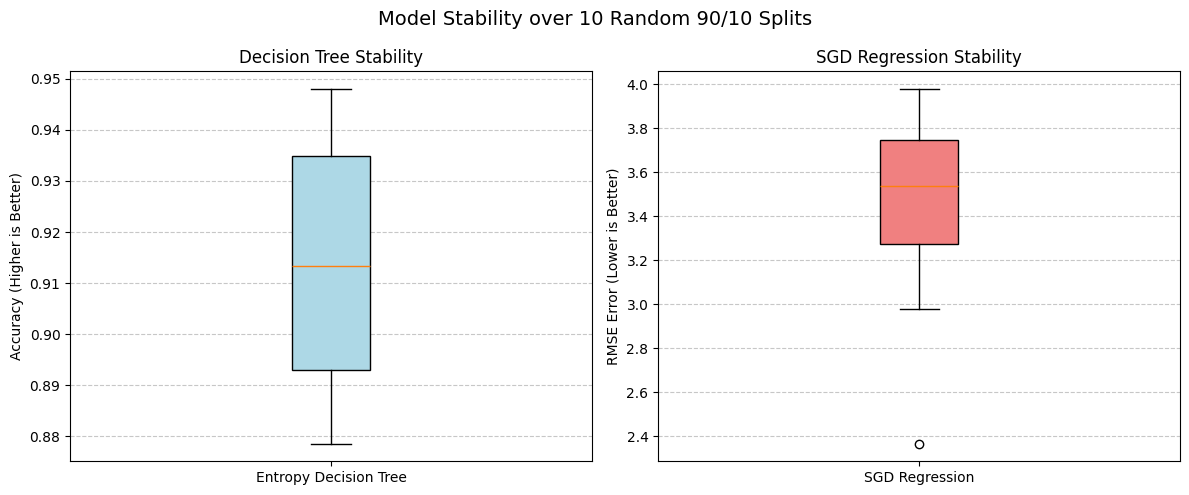

In [9]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Number of runs r >= 5
num_runs = 10
dt_accuracies = []
sgd_rmses = []

print(f"Running stability test over {num_runs} runs...")

for r in range(num_runs):
    # ==========================================
    # Classification: Decision Tree
    # ==========================================
    # Randomly shuffle and split 90% train, 10% test
    X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(X_car, y_car, test_size=0.10, random_state=r, stratify=y_car)
    
    # We must encode the labels to integers again for the new splits
    le = LabelEncoder()
    y_c_tr_enc = le.fit_transform(y_c_tr)
    y_c_te_enc = le.transform(y_c_te)
    
    # Train using the best depth found in Task 5 (if None, fallback to 5)
    best_depth = best_max_depth if best_max_depth is not None else 5
    model_dt = EntropyDecisionTree(max_depth=best_depth)
    model_dt.fit(X_c_tr.to_numpy(), y_c_tr_enc)
    
    # Predict and record accuracy
    pred_dt = model_dt.predict(X_c_te.to_numpy())
    acc = accuracy_score(y_c_te_enc, pred_dt)
    dt_accuracies.append(acc)
    
    # ==========================================
    # Regression: SGD Regression
    # ==========================================
    # Randomly shuffle and split 90% train, 10% test
    X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_mpg, y_mpg, test_size=0.10, random_state=r)
    
    # Train using the best learning rate found in Task 5 (fallback to 0.01)
    best_learning_rate = best_lr if best_lr is not None else 0.01
    model_sgd = SGDRegression(learning_rate=best_learning_rate, n_iterations=1000)
    model_sgd.fit(X_m_tr.to_numpy(), y_m_tr)
    
    # Predict and record RMSE error
    pred_sgd = model_sgd.predict(X_m_te.to_numpy())
    rmse = np.sqrt(mean_squared_error(y_m_te, pred_sgd))
    sgd_rmses.append(rmse)


# ---------------------------------------------------------
# Report Mean and Standard Deviation
# ---------------------------------------------------------
print("\n--- Decision Tree (Classification) Stability ---")
print(f"Accuracy Mean:    {np.mean(dt_accuracies):.4f}")
print(f"Accuracy Std Dev: {np.std(dt_accuracies):.4f}")

print("\n--- SGD Regression (Regression) Stability ---")
print(f"RMSE Error Mean:    {np.mean(sgd_rmses):.4f}")
print(f"RMSE Error Std Dev: {np.std(sgd_rmses):.4f}")


# ---------------------------------------------------------
# Plotting Boxplots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot 1: Decision Tree
axes[0].boxplot(dt_accuracies, patch_artist=True, boxprops=dict(facecolor="lightblue"))
axes[0].set_title('Decision Tree Stability')
axes[0].set_ylabel('Accuracy (Higher is Better)')
axes[0].set_xticklabels(['Entropy Decision Tree'])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot 2: SGD Regression
axes[1].boxplot(sgd_rmses, patch_artist=True, boxprops=dict(facecolor="lightcoral"))
axes[1].set_title('SGD Regression Stability')
axes[1].set_ylabel('RMSE Error (Lower is Better)')
axes[1].set_xticklabels(['SGD Regression'])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Model Stability over 10 Random 90/10 Splits", fontsize=14)
plt.tight_layout()
plt.show()
